## Imports and utilitaries

Run all cells in this section before simulating.


In [1]:
# copied from all_possible_paths.py
 
### In this script I can try all the different combinations of actions for the AV agents.
import itertools
import os
import pandas as pd
import numpy as np
import latex
import scienceplots
import csv
import torch
from tensordict.nn import TensorDictModule, TensorDictSequential
from torchrl.envs.libs.pettingzoo import PettingZooWrapper
from torchrl.envs.transforms import TransformedEnv, RewardSum
from torchrl.envs.utils import check_env_specs
from torch import nn
from torchrl._utils import logger as torchrl_logger
from torchrl.collectors import SyncDataCollector
from torchrl.data import TensorDictReplayBuffer
from torchrl.data.replay_buffers.samplers import SamplerWithoutReplacement
from torchrl.data.replay_buffers.storages import LazyTensorStorage
from torchrl.modules import EGreedyModule, QValueModule, SafeSequential
from torchrl.modules.models.multiagent import MultiAgentMLP
from torchrl.objectives import SoftUpdate, ValueEstimators, DQNLoss

from routerl import TrafficEnvironment

from routerl.keychain import Keychain as kc
from routerl.utilities import get_params

os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

import matplotlib.lines as lines
import matplotlib.patches as patches
from matplotlib.patches import ConnectionPatch

viridis = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=5, vmax=10)

C:\Users\Utilisateur\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torchrl\data\replay_buffers\samplers.py:37: UserWarning: Failed to import torchrl C++ binaries. Some modules (eg, prioritized replay buffers) may not work with your installation. This is likely due to a discrepancy between your package version and the PyTorch version. Make sure both are compatible. Usually, torchrl majors follow the pytorch majors within a few days around the release. For instance, TorchRL 0.5 requires PyTorch 2.4.0, and TorchRL 0.6 requires PyTorch 2.5.0.
  warnings.warn(EXTENSION_WARNING)


### Data structures and objects

`id` is a number between 0 and 1023, referencing one of the 1024 possible joint actions of the players and the id'th line of a payoff matrix.

`strategy` is an array of size 10, where `strategy[i]` indicates the route choice of player `i`.

`coalition` is an array, containing a subset of [0..9].

In [2]:
def id_to_strategy(id):
    '''
    INPUT :`id`= integer from`[0,1023]`

    OUTPUT :`strategy`= array of size 10, binary representation of number`id`
    '''
    strategy = [0 for _ in range(10)]
    i = 0
    while id > 0:
        if id % 2 == 1:
            strategy[9-i] = 1
        id = id//2
        i += 1
    return strategy


In [3]:
def strategy_to_id(s):
    '''
    INPUT :`strategy`= array of size 10, binary representation of number`id`

    OUTPUT :`id`= integer within`[0,1023]`
    '''
    id = 0
    for i in range(10):
        id += s[i]*(2**(9-i))
    return id


In [4]:
def coalition_to_strategy(coalition):
    '''
    INPUT :`coalition`= subset of [0,9]

    OUTPUT :`strategy`= array of size 10,`strategy[i] = 1`iff i is in the coalition

    NOTE :`strategy_to_coalition(id_to_strategy())`may be used to map an integer to a subset of [0,9]
    '''
    s = [0 for _ in range(10)]
    for i in coalition:
        s[i] = 1
    return s


In [5]:
def strategy_to_coalition(s):
    '''
    INPUT :`strategy`= array of size 10
    
    OUTPUT :`coalition`= subset of [0,9],`strategy[i] = 1`iff i is in the coalition

    NOTE :`strategy_to_coalition(id_to_strategy())`may be used to map an integer to a subset of [0,9]
    '''
    coalition = []
    for i in range(10):
        if s[i] == 1:
            coalition.append(i)
    return coalition


In [6]:
def neighbouring_strategies(s):

    '''
    INPUT :`s`= array of size n, describing the joint actions of the 10 AVs (route 0 or 1) \\
    OUTPUT : array of all 10 joint actions, each one with one of the AVs deviating from`s`
    '''

    neigh = [ [s[j] for j in range(10)] for _ in range(10)]
    for i in range(10):
        neigh[i][i] = 1 - neigh[i][i]
    return neigh


In [7]:
def neighbouring_ids(id):
    
    '''
    goes from the space of ids (integers in`0..1023`) to strategies, then to neighbouring strategies (see`neighbouring_strategies()`), and back to ids.
    '''

    s = id_to_strategy(id)
    t = neighbouring_strategies(s)
    neigh = []
    for i in range(10):
        neigh.append(strategy_to_id(t[i]))
    return neigh


### Building reward tables

Functions to build a 10x1024 payoff matrix from a given experiment record or from custom dynamic traffic light parameters, and access it through the objects.

In [8]:
def build_rewardtable(file_name):

    '''
    Returns the payoff matrix from an experiment (stored in the file given as input) as an array.

    !! Will crash if the file does not exist.
    '''

    df_reward = pd.read_csv(file_name)
    tab = np.zeros((10,1024))
    for i in range(10):
        tab[i] = df_reward[str(i)].values
    return tab


In [9]:
def custom_df(tl_list, custom_filename = "reward_df_custom.csv"):

    '''
    `tl_list`is an array of size 11. For each i in [0...10],`tl_list[i]`is a tuple`(tl_0,tl_1,tl_y,nb_agents)`, representing specific parameters of a network with static traffic lights.

    `custom_df`builds the payoff matrix of a network with dynamic traffic lights, where whenever n AVs choose route 1, traffic lights are set to`tl_list[n]`
    '''

    assert len(tl_list) == 11

    f = open(custom_filename,"w")
    
    f.write("id,0,1,2,3,4,5,6,7,8,9\n")
    for id in range(1024):

        s = id_to_strategy(id)
        n_1 = 0
        for j in range(10):
            n_1 += s[j]
        tl_0,tl_1,tl_y,nb_agents = tl_list[n_1]

        try:
            df_reward = pd.read_csv("reward_df_%s_%s_%s_%sagents.csv"%(tl_0,tl_1,tl_y,nb_agents))
        except:
            print("Reward table for tl_0 = %s, tl_1 = %s, tl_y = %s and %s agents was not found. Running..."%(tl_0,tl_1,tl_y,nb_agents))
            run(tl_0,tl_1,tl_y,nb_agents)
            df_reward = pd.read_csv("reward_df_%s_%s_%s_%sagents.csv"%(tl_0,tl_1,tl_y,nb_agents))

        text = str(id)
        tab_reward = [[] for _ in range(10)]
        for i in range(10):
            tab_reward[i] = df_reward[str(i)].values
            text = text + "," + str(float(tab_reward[i][id]))

        f.write(text+"\n")

In [10]:
def reward(i,id):
    return float(tab_reward[i][id])


In [11]:
def id_to_reward(id):
    return [reward(i,id) for i in range(10)]


In [12]:
def s_to_reward(s):
    id = strategy_to_id(s)
    return id_to_reward(id)


In [13]:
def travel_times(id):
    s = id_to_strategy(id)
    t0 = 0
    t1 = 0
    n0 = 0
    n1 = 0
    les_t = tab_reward[:,id]
    for i in range(10):
        if s[i] == 0:
            n0 += 1
            t0 += les_t[i]
        else:
            n1 += 1
            t1 += les_t[i]
    if n0 > 0:
        t0 = t0/n0
    if n1 > 0:
        t1 = t1/n1
    return n0, n1, -t0, -t1


In [14]:
def normalized_travel_times(id,p0):
    s = id_to_strategy(id)
    t0 = 0
    t1 = 0
    n0 = 0
    n1 = 0
    les_t = tab_reward[:,id]
    for i in range(10):
        if s[i] == 0:
            n0 += 1
            t0 += les_t[i]/p0[i]
        else:
            n1 += 1
            t1 += les_t[i]/p0[i]
    if n0 > 0:
        t0 = t0/n0
    if n1 > 0:
        t1 = t1/n1
    return n0, n1, t0, t1

### Algorithms for Nash and strong equilibria

In [15]:
def nash_deviation(s):
    
    '''
    for a given strategy/joint action`s`, returns an array of size 10`dev`.

    For i in 0..9,`dev[i]`is what the AV number i can gain by deviating ALONE from`s`.
    '''

    rew = s_to_reward(s)
    neigh = neighbouring_strategies(s)
    dev = []
    for i in range(10):
        alternative = s_to_reward(neigh[i])[i]
        dev.append(alternative - rew[i])
    return dev


In [16]:
def nash_equilibrium(s):
    
    '''
    runs`nash_deviation(s)`, verifies if any AV can gain by deviating from`s`, and answers whether`s`is a Nash equilibrium.
    '''

    dev = nash_deviation(s)
    for i in range(10):
        if dev[i] > 0:
            return False
    return True


In [17]:
def strong_nash_equilibrium(s,verbose=True):
    
    '''
    verifies that no subset (aka coalition) of the set of AVs can deviate from`s`. \\
    A coalition deviates if every member increases its payoff when the whole coalition deviates.\\
    Add `verbose=False` if you do not want to print coalitions eligible for a deviation.
    '''

    rew = s_to_reward(s)
    list_c = []
    for id in range(1,1024):
        coalition = strategy_to_coalition(id_to_strategy(id))
        neigh_s = [s[i] for i in range(10)]
        for i in coalition:
            neigh_s[i] = 1 - s[i]
        alt = s_to_reward(neigh_s)
        coalition_deviates = True
        for i in coalition:
            if alt[i] - rew[i] <= 0:
                coalition_deviates = False
        if coalition_deviates:
            list_c.append(coalition)
    if verbose:
        for c in list_c:
            print(c)
    return len(list_c) == 0


In [18]:
def individual_deviations(s):
    
    '''
    runs`nash_deviation(s)`, and returns the list of AVs that can gain by deviating from`s`.
    '''

    dev = nash_deviation(s)
    list_i = []
    for i in range(10):
        # we do not verify if the first AV can deviate. Otherwise, no non-trivial NE will be found.
        if dev[i] > 0:
            list_i.append(i)
    return list_i

In [19]:
def coalition_deviations(s):
    
    '''
    Returns coalitions that may deviate from `s`.
    '''

    rew = s_to_reward(s)
    list_c = []
    for id in range(1,1024):
        coalition = strategy_to_coalition(id_to_strategy(id))
        neigh_s = [s[i] for i in range(10)]
        for i in coalition:
            neigh_s[i] = 1 - s[i]
        alt = s_to_reward(neigh_s)
        coalition_deviates = True
        for i in coalition:
            if alt[i] - rew[i] <= 0:
                coalition_deviates = False
        if coalition_deviates:
            list_c.append(coalition)
    return list_c

In [20]:
def plot_deviation(club,p0):

    '''
    Input : `club` is a subset of the set of players.
    Output : `y` is the reward of all players if the club goes to route 1 and all other players go to route 0. \\
            `y_dev` is the reward of each player if they deviate alone from this situation.
    '''

    s = coalition_to_strategy(club)
    print("#######################\nClub is %s.\tJoint action is %s"%(club,s))
    print("List of agents that could deviate individually: \t",individual_deviations(s))
    print("List of coalitions that could deviate simultaneously: \t",coalition_deviations(s))
    print("Nash equilibrium: %s, strong equilibrium: %s"%(nash_equilibrium(s),strong_nash_equilibrium(s,verbose=False)))
    p = s_to_reward(s)
    nash_dev = nash_deviation(s)
    y = [p[i]/p0[i] for i in range(len(p))]
    dev = [nash_dev[i]/p0[i] for i in range(10)]
    return y,dev,s

### Define parameters

Since this file is only used to plot results from one network, let's set the parameters once and for all.

In [21]:
# Define system parameters
nb_agents = 15      # number of human + AV agents in the network
threshold = 3       # number of AVs on route 1 beyond which the traffic lights adapt
tl_y = 5            # length of each yellow light phase
cycle_length = 50   # total length of the traffic light cycle

tl_0_below_threshold = 21   # how long the green light lasts on route 0 before traffic lights adapt
tl_0_above_threshold = 9    # how long the green light lasts on route 0 after traffic lights adapt
# and idem on route 1:
tl_1_below_threshold = cycle_length - 2*tl_y  - tl_0_below_threshold
tl_1_above_threshold = cycle_length - 2*tl_y  - tl_0_above_threshold

# payoff matrix
tl_list = [(tl_0_below_threshold,tl_1_below_threshold,tl_y,nb_agents) if nb_1 < threshold else (tl_0_above_threshold,tl_1_above_threshold,tl_y,nb_agents) for nb_1 in range(11)]
custom_df(tl_list)
tab_reward = build_rewardtable("reward_df_custom.csv")

# Calculating deviations from the initial situation
s_0 = id_to_strategy(0)
print("#######################\nInitial situation: everyone on route 0.")
print("List of clubs that may form from x^0: \t",coalition_deviations(s_0))
print("Nash equilibrium: %s, strong equilibrium: %s"%(nash_equilibrium(s_0),strong_nash_equilibrium(s_0,verbose=False)))
p_0 = s_to_reward(s_0)
nash_dev = nash_deviation(s_0)

#######################
Initial situation: everyone on route 0.
List of clubs that may form from x^0: 	 [[1, 5, 6]]
Nash equilibrium: True, strong equilibrium: False


## Testing scripts, sample code

In [30]:
print("Nash equilbrium: %s, strong equilibrium: %s"%(nash_equilibrium(s_0),strong_nash_equilibrium(s_0,verbose=False)))

Nash equilbrium: True, strong equilibrium: False


#######################
Club is [].	Joint action is [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
List of agents that could deviate individually: 	 []
List of coalitions that could deviate simultaneously: 	 [[1, 5, 6]]
Nash equilibrium: True, strong equilibrium: False
#######################
Club is [1, 5, 6].	Joint action is [0, 1, 0, 0, 0, 1, 1, 0, 0, 0]
List of agents that could deviate individually: 	 [0, 7]
List of coalitions that could deviate simultaneously: 	 [[7], [0], [0, 4]]
Nash equilibrium: False, strong equilibrium: False
#######################
Club is [0, 1, 5, 6].	Joint action is [1, 1, 0, 0, 0, 1, 1, 0, 0, 0]
List of agents that could deviate individually: 	 []
List of coalitions that could deviate simultaneously: 	 []
Nash equilibrium: True, strong equilibrium: True
#######################
Club is [1, 5, 6, 7].	Joint action is [0, 1, 0, 0, 0, 1, 1, 1, 0, 0]
List of agents that could deviate individually: 	 [0]
List of coalitions that could deviate simultaneously: 	 [[0], [0, 4]]
Na

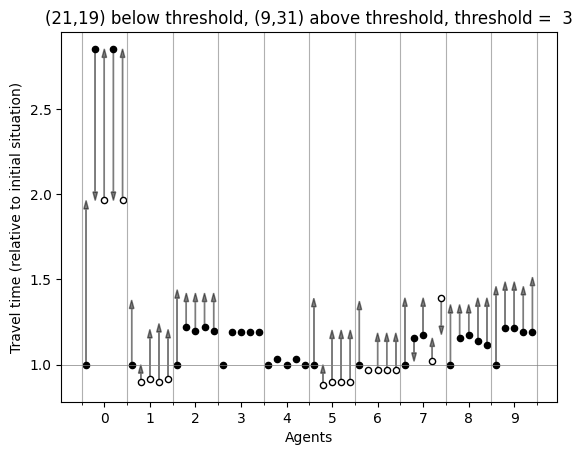

In [22]:
# Preparing the plot
les_x = [i for i in range(10)]
plt.style.use("default")
# plt.style.use('science')
fig, ax = plt.subplots()
ax.set_xticks([i - 0.5 for i in range(11)], minor=True)
ax.set_xticks([i  for i in range(10)], minor=False)
ax.set_yticks([0,0.5,1,1.5,2,2.5], minor = False)
ax.set_yticks([1], minor = True)
plt.grid(which="minor")
ax.axhline(1, color='gray', linewidth=0.5)

def plot_clubs(club,shift):
    '''
    Computes payoffs and deviations from the joint action where `club` is on route 1 and everyone else on route 0. \\
    Then, plots the results. Use `shift` to display several results side by side without overlapping.
    '''
    les_y,les_dev,s = plot_deviation(club,p_0)
    for i in range(10):
        ax.arrow(i+shift,les_y[i],0,les_dev[i],head_width = 0.1, head_length = min(0.05,np.abs(les_dev[i])),length_includes_head = True,color='0',alpha=0.5)
        ax.scatter(i+shift,les_y[i],color=str(s[i]),edgecolor='0',sizes=[20])
        # ax.plot([i + shift,i + shift],les_yplusdev[i],color=color,alpha=0.5)

plot_clubs([],-0.4)
plot_clubs([1,5,6],-0.2)
plot_clubs([0,1,5,6],0)
plot_clubs([1,5,6,7],0.2)
plot_clubs([0,1,5,6,7],0.4)

ax.set_xlabel("Agents")
ax.set_ylabel("Travel time (relative to initial situation)")
plt.title("(%s,%s) below threshold, (%s,%s) above threshold, threshold =  %s"%(tl_0_below_threshold,tl_1_below_threshold,tl_0_above_threshold,tl_1_above_threshold,threshold))
plt.show()

#######################
Club is [].	Joint action is [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
List of agents that could deviate individually: 	 []
List of coalitions that could deviate simultaneously: 	 [[1, 5, 6]]
Nash equilibrium: True, strong equilibrium: False
#######################
Club is [1, 5, 6].	Joint action is [0, 1, 0, 0, 0, 1, 1, 0, 0, 0]
List of agents that could deviate individually: 	 [0, 7]
List of coalitions that could deviate simultaneously: 	 [[7], [0], [0, 4]]
Nash equilibrium: False, strong equilibrium: False
#######################
Club is [1, 5, 6, 7].	Joint action is [0, 1, 0, 0, 0, 1, 1, 1, 0, 0]
List of agents that could deviate individually: 	 [0]
List of coalitions that could deviate simultaneously: 	 [[0], [0, 4]]
Nash equilibrium: False, strong equilibrium: False
#######################
Club is [0, 1, 5, 6, 7].	Joint action is [1, 1, 0, 0, 0, 1, 1, 1, 0, 0]
List of agents that could deviate individually: 	 [7]
List of coalitions that could deviate simultaneously: 	

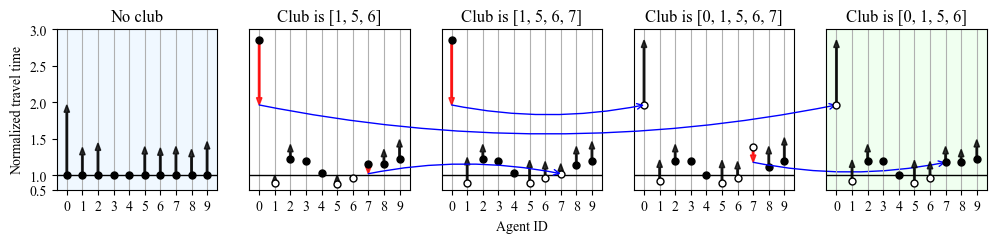

In [24]:
# Preparing the plot
les_x = [i for i in range(10)]
plt.style.use("default")
tnrfont = {'fontname':'Times New Roman'}
# plt.style.use('science')
fig = plt.figure()
fig.set_size_inches(12,3)
list_clubs = [[],[1,5,6],[1,5,6,7],[0,1,5,6,7],[0,1,5,6]]
nb_clubs_tested = len(list_clubs)
les_ax = []

les_xy = []

def plot_clubs(club,shift):
    '''
    Computes payoffs and deviations from the joint action where `club` is on route 1 and everyone else on route 0. \\
    Then, plots the results. Use `shift` to display several results side by side without overlapping.
    '''
    les_y,les_dev,s = plot_deviation(club,p_0)
    for i in range(10):
        color = '0'
        if les_dev[i] < 0:
            color = 'r'
            les_xy.append((les_x[i],les_y[i] + les_dev[i]))
        les_ax[-1].arrow(i+shift,les_y[i],0,les_dev[i],width=0.1,head_width = 0.35, head_length = min(0.1,np.abs(les_dev[i])),length_includes_head = True,color=color,zorder=2,alpha = 0.8)
        if s[i] == 0:
            les_ax[-1].plot(i+shift,les_y[i],"o",markerfacecolor='0',markeredgecolor='0',markersize=5,zorder=3)
        else:
            les_ax[-1].plot(i+shift,les_y[i],"o",markerfacecolor='1',markeredgecolor='0',markersize=5,zorder=3)
        plt.draw()
        # ax.plot([i + shift,i + shift],les_yplusdev[i],color=color,alpha=0.5)

for n in range(nb_clubs_tested):
    club = list_clubs[n]
    les_ax.append(fig.add_subplot(1,nb_clubs_tested,n+1))
    les_ax[-1].set_ylim(0.8,3)
    les_ax[-1].set_xticks([i  for i in range(10)], minor=False, )
    les_ax[-1].set_xticklabels(les_ax[-1].get_xticks(), **tnrfont)
    les_ax[-1].set_yticklabels(les_ax[-1].get_yticks(), **tnrfont)
    les_ax[-1].grid(axis="x",which="major",zorder=0)
    les_ax[-1].yaxis.set_visible(False)
    les_ax[-1].axhline(1, color='0', linewidth=1)
    title = "Club is %s"%(club) if n > 0 else "No club"
    les_ax[-1].set_title(title,**tnrfont)
    les_ax[-1].set_box_aspect(1)
    plot_clubs(club,0)
    plt.draw()

print(les_xy)
con = ConnectionPatch(xyA=les_xy[0], xyB=les_xy[0], connectionstyle="arc3,rad=.1", coordsA="data", coordsB="data",axesA=les_ax[1], axesB=les_ax[4], color="b",arrowstyle="->")
les_ax[4].add_artist(con)
con = ConnectionPatch(xyA=les_xy[1], xyB=les_xy[1], connectionstyle="arc3,rad=-0.1", coordsA="data", coordsB="data",axesA=les_ax[1], axesB=les_ax[2], color="b",arrowstyle="->")
les_ax[4].add_artist(con)
con = ConnectionPatch(xyA=les_xy[2], xyB=les_xy[2], connectionstyle="arc3,rad=.1", coordsA="data", coordsB="data",axesA=les_ax[2], axesB=les_ax[3], color="b",arrowstyle="->")
les_ax[4].add_artist(con)
con = ConnectionPatch(xyA=les_xy[3], xyB=les_xy[3], connectionstyle="arc3,rad=.1", coordsA="data", coordsB="data",axesA=les_ax[3], axesB=les_ax[4], color="b",arrowstyle="->")
les_ax[4].add_artist(con)

#ax1.plot(x[i],y[i],'ro',markersize=10)
#ax2.plot(x[i],y[i],'ro',markersize=10)
les_ax[0].yaxis.set_visible(True)
les_ax[0].set_ylabel("Normalized travel time",**tnrfont)
les_ax[0].set_yticks([0.8,1,1.5,2,2.5,3], minor = False)
les_ax[0].set_facecolor('aliceblue')
les_ax[4].set_facecolor('honeydew')
les_ax[2].set_xlabel("Agent ID",**tnrfont)

black_dot = lines.Line2D([0], [0], color = "w", marker="o",markerfacecolor='0',markeredgecolor='0',markersize=8)
white_dot = lines.Line2D([0], [0], color = "w", marker="o",markerfacecolor='1',markeredgecolor='0',markersize=8)

# leg = plt.legend([black_dot, white_dot], ["Agent on route 0", "Agent on route 1"],loc = 'upper right')

# plt.title("(%s,%s) below threshold, (%s,%s) above threshold, threshold =  %s"%(tl_0_below_threshold,tl_1_below_threshold,tl_0_above_threshold,tl_1_above_threshold,threshold))
plt.savefig("deviations.png")
plt.show()

##  Find all clubs and explore their stability

In [34]:
# Calculating deviations from the initial situation
print("#######################\nInitial situation: everyone on route 0.")
c_dev = coalition_deviations(s_0)
print("List of clubs that may form from x^0:",c_dev)
rew_0 = s_to_reward(s_0)
print("Payoffs:",rew_0)
print("Nash equilibrium: %s, strong equilibrium: %s"%(nash_equilibrium(s_0),strong_nash_equilibrium(s_0,verbose=False)))

def explore_deviations(club,nb_tabs=1):
    s = coalition_to_strategy(club)
    print(nb_tabs*"\t"+"#######################\n"+nb_tabs*"\t"+"Club is %s."%(club))
    ind_dev = individual_deviations(s)
    print(nb_tabs*"\t"+"List of agents that could deviate individually: %s"%ind_dev)
    new_c_dev = []
    for new_c in coalition_deviations(s):
        outofclub = True
        for i in new_c:
            if i in club:
                outofclub = False
        if outofclub:
            new_c_dev.append(new_c)
    print(nb_tabs*"\t"+"List of coalitions that could deviate simultaneously: %s"%new_c_dev)

    rew = s_to_reward(s)
    print(nb_tabs*"\t"+"Payoffs: %s"%rew)
    print(nb_tabs*"\t"+"Nash equilibrium: %s, strong equilibrium: %s"%(nash_equilibrium(s),strong_nash_equilibrium(s,verbose=False)))

    # checking club internal stability (nobody wants to quit)
    internal_stability = True
    for i in club:
        if i in ind_dev:
            internal_stability = False
    if not internal_stability:
        print(nb_tabs*"\t"+"Club is not internally stable (at least one member of the club wants to deviate)")
    
    for i in club:
        print(nb_tabs*"\t"+"%s gains %s from being in the club"%(i,rew[i] - rew_0[i]))
    for new_c in new_c_dev:
        explore_deviations(club + new_c,nb_tabs+1)
    
    return None

for c in c_dev:
    explore_deviations(c)

#######################
Initial situation: everyone on route 0.
List of clubs that may form from x^0: [[1, 5, 6]]
Payoffs: [-0.45, -0.9666666666666668, -0.8333333333333334, -1.0333333333333334, -0.4833333333333333, -0.9833333333333332, -0.9833333333333332, -0.85, -0.85, -0.6166666666666667]
Nash equilibrium: True, strong equilibrium: False
	#######################
	Club is [1, 5, 6].
	List of agents that could deviate individually: [0, 7]
	List of coalitions that could deviate simultaneously: [[7], [0], [0, 4]]
	Payoffs: [-1.2833333333333334, -0.8666666666666667, -1.0166666666666666, -1.2333333333333334, -0.5, -0.8666666666666667, -0.95, -0.9833333333333332, -0.9833333333333332, -0.75]
	Nash equilibrium: False, strong equilibrium: False
	1 gains 0.10000000000000009 from being in the club
	5 gains 0.11666666666666647 from being in the club
	6 gains 0.033333333333333215 from being in the club
		#######################
		Club is [1, 5, 6, 7].
		List of agents that could deviate individual

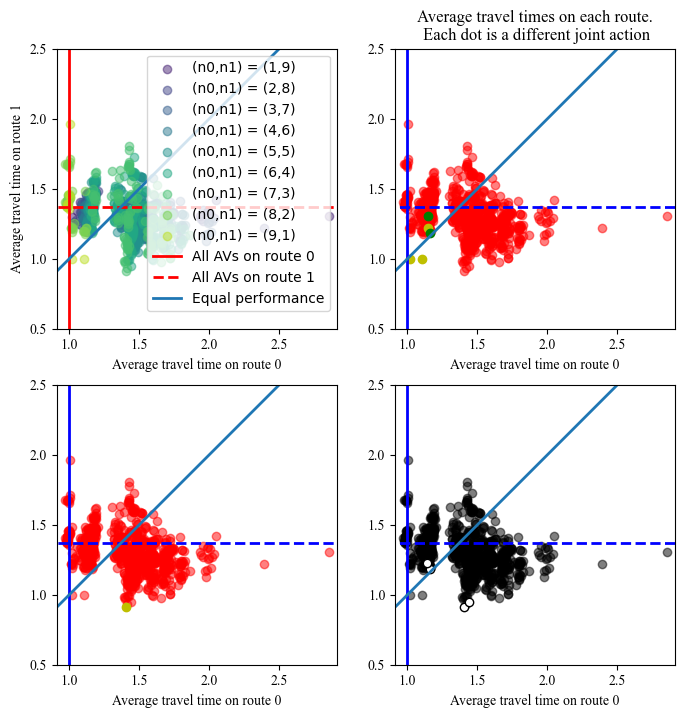

In [26]:
## Compute Nash equilibria and deviations

les_t0 = [[] for n0 in range(11)]
les_t1 = [[] for n0 in range(11)]

snash_x, snash_y = [], []
nash_x, nash_y = [], []
notnash_x, notnash_y = [], []

dev_x, dev_y = [], []
sdev_x, sdev_y = [], []
notdev_x, notdev_y = [], []

list_clubs = [[],[1,5,6],[1,5,6,7],[0,1,5,6,7],[0,1,5,6]]
# list_clubs = [[4,5,9]]
list_clubs_ids = [strategy_to_id(coalition_to_strategy(c)) for c in list_clubs]
clubs_x, clubs_y = [], []
notclubs_x, notclubs_y = [], []

rew = id_to_reward(0)
list_c = []

for id in range(1024):
    # n0,n1,t0,t1 = travel_times(id)
    n0,n1,t0,t1 = normalized_travel_times(id,p_0)
    les_t0[n0].append(t0)
    les_t1[n0].append(t1)

    if n0*n1 > 0: # we remove the dots (n0,n1) = (0,10) and (n0,n1) = (10,0)
        if nash_equilibrium(id_to_strategy(id)):
            if strong_nash_equilibrium(id_to_strategy(id),verbose=False):
                snash_x.append(t0)
                snash_y.append(t1)
            else:
                nash_x.append(t0)
                nash_y.append(t1)
        else:
            notnash_x.append(t0)
            notnash_y.append(t1)
    
        s = id_to_strategy(id)
        coalition = strategy_to_coalition(s)
        alt = s_to_reward(s)
        coalition_deviates = True
        for i in coalition:
            if alt[i] - rew[i] <= 0:
                coalition_deviates = False
        if coalition_deviates:
            if n1 == 1:
                dev_x.append(t0)
                dev_y.append(t1)
            else:
                sdev_x.append(t0)
                sdev_y.append(t1)
        else:
            notdev_x.append(t0)
            notdev_y.append(t1)
        
        if id in list_clubs_ids:
            clubs_x.append(t0)
            clubs_y.append(t1)
        else:
            notclubs_x.append(t0)
            notclubs_y.append(t1)

# Drawing plots

fig = plt.figure()
fig.set_size_inches(8,8)
tnrfont = {'fontname':'Times New Roman'}

## Drawing the first plot (colors depend on the flow on each route)

ax = fig.add_subplot(2,2,1)

for n0 in range(1,10):
    ax.scatter(les_t0[n0],les_t1[n0],label="(n0,n1) = (%s,%s)"%(n0,10-n0),alpha = 0.5,color = viridis(n0/10))

ax.set_xlabel("Average travel time on route 0", **tnrfont)
ax.set_ylabel("Average travel time on route 1", **tnrfont)
ax.set_yticks([i/10 for i in range(5,30,5)])
ax.set_xticklabels(ax.get_xticks(), **tnrfont)
ax.set_yticklabels(ax.get_yticks(), **tnrfont)

ax.add_artist(lines.Line2D([les_t0[10],les_t0[10]], [0,3], linewidth=2, color = "r", label="All AVs on route 0"))
ax.add_artist(lines.Line2D([0,3],[les_t1[0],les_t1[0]], linewidth=2,linestyle="--", color = "r", label="All AVs on route 1"))
ax.add_artist(lines.Line2D([0,3], [0,3], linewidth=2, label="Equal performance"))

ax.legend()

ax.set_aspect("equal", adjustable="datalim")
ax.set_box_aspect(1)
#leg = plt.legend( loc = 'upper left')
plt.draw()

## Drawing the second plot (colors depend on the equilibrium status)

ax2 = fig.add_subplot(2,2,2)

ax2.scatter(notnash_x,notnash_y,label="not Nash equilibrium",alpha = 0.5,color = 'r')
ax2.scatter(nash_x,nash_y,label="not strong Nash equilibrium",alpha = 1,color = 'y')
ax2.scatter(snash_x,snash_y,label="strong Nash equilibrium",alpha = 1,color = 'g')

ax2.set_xlabel("Average travel time on route 0", **tnrfont)
ax2.set_yticks([i/10 for i in range(5,30,5)])
ax2.set_xticklabels(ax2.get_xticks(), **tnrfont)
ax2.set_yticklabels(ax2.get_yticks(), **tnrfont)

ax2.add_artist(lines.Line2D([les_t0[10],les_t0[10]], [0,3], linewidth=2, color = "b", label="All AVs on route 0"))
ax2.add_artist(lines.Line2D([0,3],[les_t1[0],les_t1[0]], linewidth=2,linestyle="--", color = "b", label="All AVs on route 1"))
ax2.add_artist(lines.Line2D([0,3], [0,3], linewidth=2, label="Equal performance"))

ax2.set_aspect("equal", adjustable="datalim")
ax2.set_box_aspect(1)
#leg = plt.legend( loc = 'upper center')
ax2.set_title("Average travel times on each route.\n Each dot is a different joint action", **tnrfont)
plt.draw()


## Drawing the third plot (colors depend on how interesting the deviation is)

ax3 = fig.add_subplot(2,2,3)

ax3.scatter(notdev_x,notdev_y,label="uninteresting deviation",alpha = 0.5,color = 'r')
ax3.scatter(dev_x,dev_y,label="individual deviation",alpha = 1,color = 'g')
ax3.scatter(sdev_x,sdev_y,label="coalitional deviation",alpha = 1,color = 'y')

ax3.set_xlabel("Average travel time on route 0", **tnrfont)
ax3.set_yticks([i/10 for i in range(5,30,5)])
ax3.set_xticklabels(ax3.get_xticks(), **tnrfont)
ax3.set_yticklabels(ax3.get_yticks(), **tnrfont)

ax3.add_artist(lines.Line2D([les_t0[10],les_t0[10]], [0,3], linewidth=2, color = "b", label="All AVs on route 0"))
ax3.add_artist(lines.Line2D([0,3],[les_t1[0],les_t1[0]], linewidth=2,linestyle="--", color = "b", label="All AVs on route 1"))
ax3.add_artist(lines.Line2D([0,3], [0,3], linewidth=2, label="Equal performance"))

ax3.set_aspect("equal", adjustable="datalim")
ax3.set_box_aspect(1)
#leg = plt.legend( loc = 'upper right')
plt.draw() 

## Drawing the third plot (colors depend on how interesting the deviation is)

ax4 = fig.add_subplot(2,2,4)

ax4.scatter(notclubs_x,notclubs_y,label="not one of the clubs tested",alpha = 0.5,color = '0')
ax4.scatter(clubs_x,clubs_y,label="clubs tested",alpha = 1,color = '1',edgecolor='0')

ax4.set_xlabel("Average travel time on route 0", **tnrfont)
ax4.set_yticks([i/10 for i in range(5,30,5)])
ax4.set_xticklabels(ax4.get_xticks(), **tnrfont)
ax4.set_yticklabels(ax4.get_yticks(), **tnrfont)

ax4.add_artist(lines.Line2D([les_t0[10],les_t0[10]], [0,3], linewidth=2, color = "b", label="All AVs on route 0"))
ax4.add_artist(lines.Line2D([0,3],[les_t1[0],les_t1[0]], linewidth=2,linestyle="--", color = "b", label="All AVs on route 1"))
ax4.add_artist(lines.Line2D([0,3], [0,3], linewidth=2, label="Equal performance"))

ax4.set_aspect("equal", adjustable="datalim")
ax4.set_box_aspect(1)
#leg = plt.legend( loc = 'upper right')
plt.draw() 

## Update the plot
plt.savefig("travel_times.png")
plt.show()

## Single actions

In [ ]:
df = pd.read_csv("rewards_club_0_1_5_6.csv")[["reward","action","kind"]]
def filter(kind):
    return df[df["kind"] == kind]

dfCDV,dfHDV = filter("AV"), filter("Human")
dfHDV["reward"].mean()

np.float64(-0.8933333333333333)

In [55]:
list = ["rewardtable_noclub.csv","rewardtable_club_1_5_6.csv","rewardtable_club_1_5_6_7.csv","rewardtable_club_0_1_5_6_7.csv","rewardtable_club_0_1_5_6.csv"]

def filter(tab, column, kind):
    return tab[tab[column] == kind]

df_x0 = pd.read_csv("rewardtable_noclub.csv")[["travel_time","action","kind"]]

AVG = []
HDV = []
CDV = []
R0 = []
R1 = []

for filename in list:
    df = pd.read_csv(filename)[["travel_time","action","kind"]]
    df["normalized_traveltime"] = df["travel_time"]/df_x0["travel_time"]
    dfCDV,dfHDV = filter(df,"kind","AV"), filter(df,"kind","Human")
    dfR0,dfR1 = filter(df,"action",0), filter(df,"action",1)

    AVG.append(df["normalized_traveltime"].mean())
    HDV.append(dfHDV["normalized_traveltime"].mean())
    CDV.append(dfCDV["normalized_traveltime"].mean())
    R0.append(dfR0["normalized_traveltime"].mean())
    R1.append(dfR1["normalized_traveltime"].mean())

    print(df["normalized_traveltime"].mean(), dfHDV["normalized_traveltime"].mean(), dfCDV["normalized_traveltime"].mean())
    print(df["normalized_traveltime"].mean(), dfR0["normalized_traveltime"].mean(), dfR1["normalized_traveltime"].mean())
    print()

1.0 1.0 1.0
1.0 1.0 nan

1.2733682313313355 1.305337882946369 1.2573834055238184
1.2733682313313355 1.3630428432261212 0.9146697837521917

1.2622388566924891 1.305337882946369 1.2406893435655493
1.2622388566924891 1.377546954859194 0.9451415867340507

1.2229333544023826 1.302059194421779 1.1833704343926847
1.2229333544023826 1.2210680607218387 1.2266639417634706

1.2142776398643151 1.302059194421779 1.1703868625855836
1.2142776398643151 1.2248183410811337 1.185290711518064



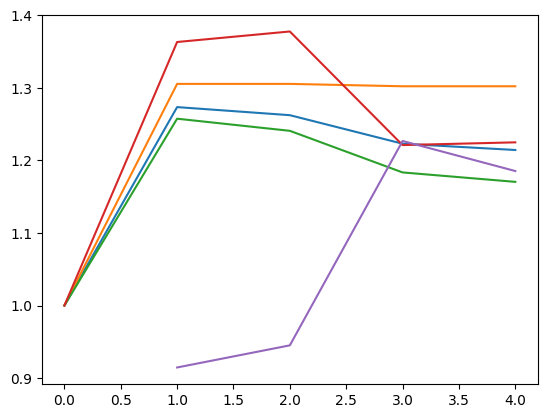

In [57]:
plt.plot([0,1,2,3,4],AVG)
plt.plot([0,1,2,3,4],HDV)
plt.plot([0,1,2,3,4],CDV)
plt.plot([0,1,2,3,4],R0)
plt.plot([0,1,2,3,4],R1)
plt.show()

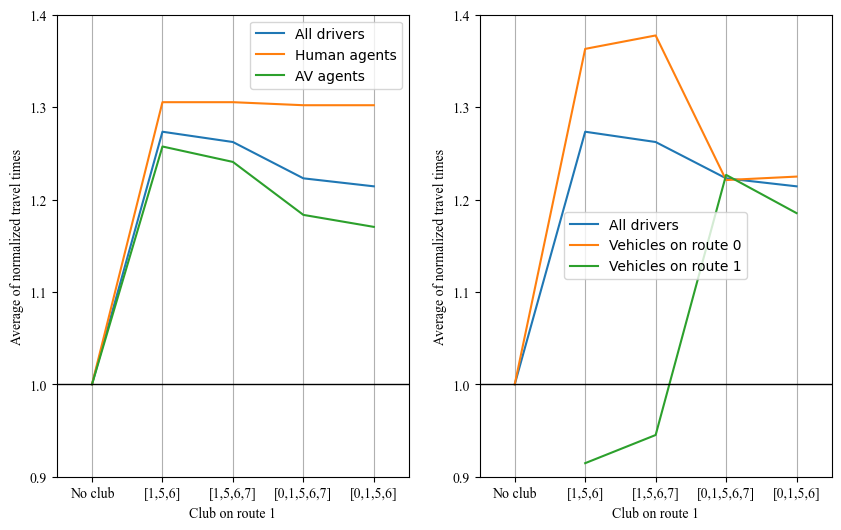

In [ ]:
fig = plt.figure()
fig.set_size_inches(10,6)
tnrfont = {'fontname':'Times New Roman'}

## 1st plot

ax = fig.add_subplot(121)
ax.plot([1,2,3,4,5],AVG, label = "All drivers")
ax.plot([1,2,3,4,5],HDV, label = "Human agents")
ax.plot([1,2,3,4,5],CDV, label = "AV agents")

ax.set_xticks([1,2,3,4,5])
ax.set_xlim(0.5,5.5)
ax.set_yticks([0.9,1,1.1,1.2,1.3,1.4])
ax.set_ylim(0.9,1.4)
ax.axhline(1, color='0', linewidth=1)
ax.grid(axis="x",which="major",zorder=0)

ax.set_xticklabels(["No club", "[1,5,6]", "[1,5,6,7]", "[0,1,5,6,7]", "[0,1,5,6]"], **tnrfont)
ax.set_yticklabels(ax.get_yticks(), **tnrfont)
ax.set_xlabel("Club on route 1", **tnrfont)
ax.set_ylabel("Average of normalized travel times", **tnrfont)

ax.legend()

## 2nd plot

ax = fig.add_subplot(122)
ax.plot([1,2,3,4,5],AVG, label = "All drivers")
ax.plot([1,2,3,4,5],R0, label = "Vehicles on route 0")
ax.plot([1,2,3,4,5],R1, label = "Vehicles on route 1")

ax.set_xticks([1,2,3,4,5])
ax.set_xlim(0.5,5.5)
ax.set_yticks([0.9,1,1.1,1.2,1.3,1.4])
ax.set_ylim(0.9,1.4)
ax.axhline(1, color='0', linewidth=1)
ax.grid(axis="x",which="major",zorder=0)

ax.set_xticklabels(["No club", "[1,5,6]", "[1,5,6,7]", "[0,1,5,6,7]", "[0,1,5,6]"], **tnrfont)
ax.set_yticklabels(ax.get_yticks(), **tnrfont)
ax.set_xlabel("Club on route 1", **tnrfont)
ax.set_ylabel("Average of normalized travel times", **tnrfont)

ax.legend()

fig.show()
